# ML Models Training for IMDb Analysis

This notebook contains training pipelines for 6 machine learning models:

## Regression Models:
1. Season Rating Difference Prediction
2. Genre Duration vs Rating Prediction
3. Rising Star Score Prediction

## Classification Models:
1. Sophomore Slump Classification
2. Hook Shows Classification
3. Underrated Genre Combos Classification

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from utils.eval import evaluate_regression_models, evaluate_classification_models, plot_model_comparison
from utils.reader import read_data
from analysis import (
    season_rating_diff,
    genre_duration_rating_analysis,
    rising_stars,
    sophomore_slump,
    hook_shows,
    underrated_genre_combos
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("IMDb-ML-Training") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print("Spark session created successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 08:28:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1
Spark session created successfully!


In [3]:
# Load data
print("Loading IMDb datasets...")
dataframes = read_data(spark)
print("\nDatasets loaded:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} rows")

Loading IMDb datasets...

Datasets loaded:


  - name.basics: 14,853,898 rows


  - title.akas: 53,865,751 rows


  - title.basics: 12,043,480 rows


  - title.crew: 12,043,480 rows


  - title.episode: 9,280,667 rows


  - title.principals: 95,660,392 rows
  - title.ratings: 1,634,159 rows


## 1. Regression Model: Season Rating Difference Prediction

**Business Question:** Can we predict the rating difference between consecutive seasons?

**Target Variable:** `rating_diff` (continuous)

**Features:** `seasonNumber`, `prev_season_rating`, genre features, region

Preparing Season Rating Difference data...

BUSINESS QUESTION: Season rating dynamics for scripted series with 3+ seasons by region


25/12/03 08:28:52 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Analyzing season rating changes for regions: ['IN', 'DE', 'FR']


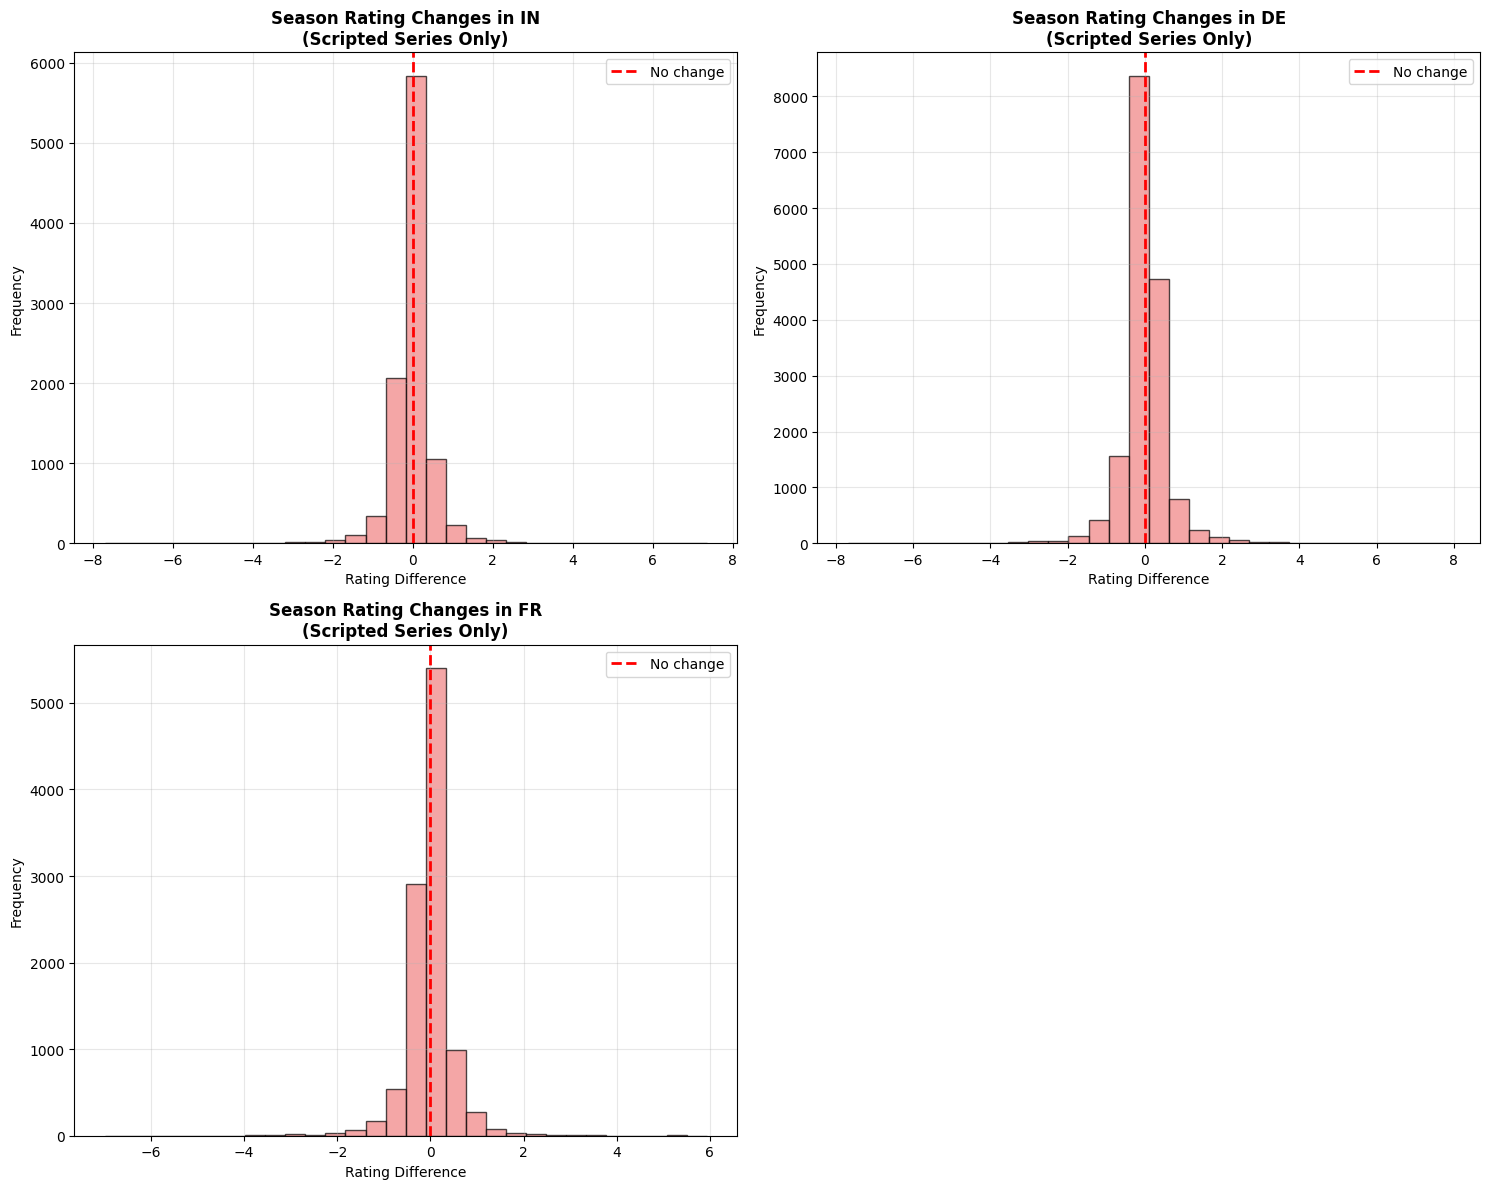

Total records: 37,023


Sample records: 11,103


In [ ]:
# Get data from season_rating_diff analysis
print("Preparing Season Rating Difference data...")
season_data = season_rating_diff(dataframes, save_path="output", top_n_regions=3)

# Sample data for faster training (adjust as needed)
sample_fraction = 0.3
season_data_sample = season_data.sample(False, sample_fraction, seed=42)

print(f"Total records: {season_data.count():,}")
print(f"Sample records: {season_data_sample.count():,}")
season_data_sample.show(5)

In [ ]:
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType

# Feature engineering for Season Rating Diff
season_features = season_data_sample.select(
    col("seasonNumber").cast(DoubleType()).alias("seasonNumber"),
    col("season_avg_rating").cast(DoubleType()).alias("current_rating"),
    col("prev_season_rating").cast(DoubleType()).alias("prev_rating"),
    col("rating_diff").cast(DoubleType()).alias("label")
).na.drop()

# Create feature vector
feature_cols = ["seasonNumber", "current_rating", "prev_rating"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
season_features = assembler.transform(season_features)

# Split data
train_data, test_data = season_features.randomSplit([0.8, 0.2], seed=42)

print(f"Training set: {train_data.count():,} records")
print(f"Test set: {test_data.count():,} records")

In [ ]:
# Train multiple regression models
print("Training regression models for Season Rating Difference...")

# 1. Linear Regression
lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# 2. Random Forest with basic params
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# 3. Gradient Boosted Trees
gbt = GBTRegressor(featuresCol="features", labelCol="label", maxIter=10, maxDepth=5)
gbt_model = gbt.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)

print("Models trained successfully!")

In [ ]:
# Evaluate models
predictions_dict = {
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosted Trees": gbt_predictions
}

results = evaluate_regression_models(predictions_dict, label_col="label")
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# Plot comparison
plot_model_comparison(results, "Season Rating Diff - Regression", save_path="output")

## 2. Regression Model: Genre Duration vs Rating

**Business Question:** Can we predict movie ratings based on genre and duration?

**Target Variable:** `averageRating`

**Features:** `runtimeMinutes`, genre features, year

In [ ]:
# Get data from genre_duration_rating_analysis
print("Preparing Genre Duration Rating data...")
genre_data = genre_duration_rating_analysis(dataframes, save_path="output", top_n_regions=3)

# Sample for faster training
genre_sample = genre_data.sample(False, 0.2, seed=42)
print(f"Sample records: {genre_sample.count():,}")
genre_sample.show(5)

In [ ]:
# Feature engineering for Genre Duration Rating
from pyspark.sql.functions import split, size

genre_features = genre_sample.select(
    col("runtimeMinutes").cast(DoubleType()).alias("runtime"),
    col("startYear").cast(DoubleType()).alias("year"),
    col("averageRating").cast(DoubleType()).alias("label")
).na.drop()

# Assemble features
feature_cols = ["runtime", "year"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
genre_features = assembler.transform(genre_features)

# Split data
train_data, test_data = genre_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

In [ ]:
# Train models with hyperparameter tuning
print("Training with hyperparameter tuning...")

# Random Forest with GridSearch on smaller sample
rf = RandomForestRegressor(featuresCol="features", labelCol="label")

# Create parameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# Use TrainValidationSplit for faster tuning
evaluator = RegressionEvaluator(labelCol="label", metricName="rmse")
tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8
)

# Fit on small sample first
small_sample = train_data.sample(False, 0.3, seed=42)
print(f"Tuning on {small_sample.count():,} records...")
tvs_model = tvs.fit(small_sample)

# Get best model and train on full data
best_rf = tvs_model.bestModel
print(f"Best params: numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getMaxDepth()}")

# Train final model with best params
final_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=best_rf.getNumTrees,
    maxDepth=best_rf.getMaxDepth()
)
final_model = final_rf.fit(train_data)
rf_predictions = final_model.transform(test_data)

# Also train baseline models
lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

print("Training complete!")

In [ ]:
# Evaluate
predictions_dict = {
    "Linear Regression": lr_predictions,
    "Random Forest (Tuned)": rf_predictions
}

results = evaluate_regression_models(predictions_dict, label_col="label")
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

plot_model_comparison(results, "Genre Duration Rating - Regression", save_path="output")

## 3. Regression Model: Rising Star Score Prediction

**Business Question:** Can we predict an actor's rising star score?

**Target Variable:** `rising_star_score`

**Features:** `avg_vote_velocity`, `avg_rating_trend`, `overall_avg_rating`

In [ ]:
# Get data from rising_stars analysis
print("Preparing Rising Stars data...")
stars_data = rising_stars(dataframes, save_path="output", top_n_regions=3)

print(f"Total records: {stars_data.count():,}")
stars_data.show(5)

In [ ]:
# Feature engineering
stars_features = stars_data.select(
    col("avg_vote_velocity").cast(DoubleType()).alias("vote_velocity"),
    col("avg_rating_trend").cast(DoubleType()).alias("rating_trend"),
    col("overall_avg_rating").cast(DoubleType()).alias("avg_rating"),
    col("rising_star_score").cast(DoubleType()).alias("label")
).na.drop()

# Assemble features
feature_cols = ["vote_velocity", "rating_trend", "avg_rating"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
stars_features = assembler.transform(stars_features)

# Scale features
scaler = StandardScaler(inputCol="raw_features", outputCol="features")
scaler_model = scaler.fit(stars_features)
stars_features = scaler_model.transform(stars_features)

# Split
train_data, test_data = stars_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

In [ ]:
# Train models
print("Training Rising Star models...")

lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Evaluate
predictions_dict = {
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions
}

results = evaluate_regression_models(predictions_dict, label_col="label")
print("\nResults:")
print(pd.DataFrame(results).to_string(index=False))

plot_model_comparison(results, "Rising Star Score - Regression", save_path="output")

## 4. Classification Model: Sophomore Slump

**Business Question:** Can we predict if a show will have a sophomore slump?

**Target Variable:** Binary (slump vs no slump)

**Features:** Season 1 rating, genre, episode count

In [ ]:
# Get data
print("Preparing Sophomore Slump data...")
slump_data, genre_stats = sophomore_slump(dataframes, save_path="output", top_n_regions=3)

print(f"Total records: {slump_data.count():,}")
slump_data.show(5)

In [ ]:
# Feature engineering for classification
from pyspark.sql.functions import when

# Create binary label: 1 if slump (delta < -0.5), 0 otherwise
slump_features = slump_data.select(
    col("rating_s1_final").cast(DoubleType()).alias("s1_rating"),
    col("rating_s2_final").cast(DoubleType()).alias("s2_rating"),
    col("delta").cast(DoubleType()).alias("delta")
).na.drop()

# Create binary label
slump_features = slump_features.withColumn(
    "label",
    when(col("delta") < -0.5, 1.0).otherwise(0.0)
)

# Assemble features
feature_cols = ["s1_rating", "s2_rating"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
slump_features = assembler.transform(slump_features)

# Check class distribution
print("Class distribution:")
slump_features.groupBy("label").count().show()

# Split
train_data, test_data = slump_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

In [ ]:
# Train classification models
print("Training Sophomore Slump classifiers...")

# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

print("Training complete!")

In [ ]:
# Evaluate classification models
from pyspark.sql.functions import col as F_col

predictions_dict = {
    "Logistic Regression": lr_predictions,
    "Random Forest": rf_predictions
}

results = evaluate_classification_models(predictions_dict, label_col="label")
print("\nResults:")
print(pd.DataFrame(results).to_string(index=False))

plot_model_comparison(results, "Sophomore Slump - Classification", save_path="output")

## 5. Classification Model: Hook Shows

**Business Question:** Can we predict if a show will hook viewers?

**Target Variable:** Binary (strong hook vs weak hook)

**Features:** First episode rating, genre, year

In [ ]:
# Get data
print("Preparing Hook Shows data...")
hook_data = hook_shows(dataframes, save_path="output", top_n_regions=3)

print(f"Total records: {hook_data.count():,}")
hook_data.show(5)

In [ ]:
# Feature engineering
# Create binary label: 1 if strong hook (delta > 0.5), 0 otherwise
hook_features = hook_data.select(
    col("first_rating").cast(DoubleType()).alias("first_rating"),
    col("last_rating").cast(DoubleType()).alias("last_rating"),
    col("delta_rating").cast(DoubleType()).alias("delta")
).na.drop()

hook_features = hook_features.withColumn(
    "label",
    when(col("delta") > 0.5, 1.0).otherwise(0.0)
)

# Assemble
feature_cols = ["first_rating", "last_rating"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
hook_features = assembler.transform(hook_features)

print("Class distribution:")
hook_features.groupBy("label").count().show()

train_data, test_data = hook_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

In [ ]:
# Train models
print("Training Hook Shows classifiers...")

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Evaluate
predictions_dict = {
    "Logistic Regression": lr_predictions,
    "Random Forest": rf_predictions
}

results = evaluate_classification_models(predictions_dict, label_col="label")
print("\nResults:")
print(pd.DataFrame(results).to_string(index=False))

plot_model_comparison(results, "Hook Shows - Classification", save_path="output")

## 6. Classification Model: Underrated Genre Combos

**Business Question:** Can we identify underrated genre combinations?

**Target Variable:** Multi-class (underrated / mainstream / niche)

**Features:** Genre combination, avg_rating, total_votes

In [ ]:
# Get data
print("Preparing Underrated Genre Combos data...")
genre_combo_data = underrated_genre_combos(dataframes, save_path="output", top_n_regions=3)

print(f"Total records: {genre_combo_data.count():,}")
genre_combo_data.show(5)

In [ ]:
# Feature engineering
# Create multi-class label based on rating and votes
genre_features = genre_combo_data.select(
    col("avg_rating").cast(DoubleType()).alias("avg_rating"),
    col("total_votes").cast(DoubleType()).alias("total_votes"),
    col("film_count").cast(DoubleType()).alias("film_count")
).na.drop()

# Create labels: 0=mainstream, 1=underrated, 2=niche
genre_features = genre_features.withColumn(
    "label",
    when((col("avg_rating") > 7.5) & (col("total_votes") < 10000), 1.0)  # underrated
    .when(col("total_votes") > 100000, 0.0)  # mainstream
    .otherwise(2.0)  # niche
)

# Assemble
feature_cols = ["avg_rating", "total_votes", "film_count"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
genre_features = assembler.transform(genre_features)

print("Class distribution:")
genre_features.groupBy("label").count().show()

train_data, test_data = genre_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

In [ ]:
# Train multi-class classifiers
print("Training Genre Combo classifiers...")

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Evaluate with multiclass metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

results = []
for name, preds in [("Logistic Regression", lr_predictions), ("Random Forest", rf_predictions)]:
    acc = evaluator_acc.evaluate(preds)
    f1 = evaluator_f1.evaluate(preds)
    results.append({"Model": name, "Accuracy": acc, "F1": f1})

print("\nResults:")
print(pd.DataFrame(results).to_string(index=False))

plot_model_comparison(results, "Genre Combos - Classification", save_path="output")